In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### PANDAS OVERVIEW

In 2008, pandas development began and by the end of 2009 it had been open sourced.
Pandas is the most powerful and flexible open source data analysis / manipulation tool available in any language.  

Pandas is a Python package providing fast, flexible, and expressive data structures. It aims to be the fundamental high-level building block for doing practical, real-world data analysis in Python. Additionally, it is the most powerful and flexible open-source data analysis/manipulation tool available in any language. For further information; https://pandas.pydata.org/docs/index.html

##### Here are just a few of the things that pandas does well:

* Easy handling of missing data(represented as NAN) in floating point as well as non-floating point data
* Size mutability: Columns can be inserted and deleted from DataFrame and higher dimensional objects
* Automatic and explicit data alignment: Object can explicitly aligned to a set of labels, or the user can simply ignore the labels and let Series, DataFrame, etc. Automatically align the data or you in computations
* Powerful, flexible group by functionality to perform split-apply-combine operations on data sets for both aggregating and transforming data
* Make it easy to convert ragged, differently-indexed data in other Python and NumPy data structures into DataFrame objects
* Intelligent label-based slicing, fancy indexing, and subsetting of large data sets
* Intuitive merging and joining data sets
* Flexible reshaping and pivoting of data sets
* Hierarchical labelling of axes
* Robust IO tools for loading data from flat files(CSV and delimited), Excel files, databases and saving/loading data from the ultrafast HDF5 format
* Time series-specific functionality: date range generation and frequency conversion, moving window statistics, date shifting, and lagging.

##### Pandas is suited for many different kinds of data:

* Tabular data with heterogeneously-typed columns, as in an SQL table or Excel spreadsheet

* Ordered and unordered (not necessarily fixed-frequency) time series data.

* Arbitrary matrix data (homogeneously typed or heterogeneous) with row and column labels

* Any other form of observational / statistical data sets. The data need not be labeled at all to be placed into a pandas data structure

## Table of Contents
* [1. Data Structures](#chapter1)
    * [1.1 Data Series](#subchapter1.1)
        * [From nd rray](#subchapter1.1.1)
        * [From dict](#subchapter1.1.2)
        * [From Scalar data](#subchapter1.1.3)
    * [1.2 DataFrame](#subchapter1.2)
        * [From dict of Series or dicts](#subchapter1.2.1)
        * [From dict of ndarrays / lists](#subchapter1.2.2)
* [2. Create Pandas DataFrame](#chapter2)
    * [Reading a CSV](#subchapter2.1)
    * [Storing a DataFrame to CSV](#subchapter2.2)
    * [Storing a DataFrame as Excel](#subchapter2.3)
* [3. Essential basic functionality](#chapter3)
* [4. Selecting and Indexing](#chapter4)
    * [How do I select columns from a DataFrame?](#subchapter4.1)
    * [How do I filter rows from a DataFrame?](#subchapter4.2)
* [5. Reshape The Layout of Tables](#chapter5)
    * [Sorting](#subchapter5.1)
    * [Pivoting](#subchapter5.2)
* [6. Descriptive Statistics](#chapter6)
    * [Summarize Data](#subchapter6.1)
    * [Aggregation](#subchapter6.2)
* [7. Working with Time Series ](#chapter7)
* [8. Working with Star Wars datasets as an Example ](#chapter8)
* [9. Create Plots in Pandas ](#chapter9)
    * [Basic Plotting: plot](#subchapter9.1)
    * [Matplotlib](#subchapter9.2)
    * [Boxplot](#subchapter9.3)
    * [Bar plot](#subchapter9.4)

### 1. Data Structures <a class="anchor"  id="chapter1"></a>
The two main data structures in Pandas are Series for 1-Dimension and DataFrame for 2-Dimension. Data in higher dimensions are supported within DataFrame using a concept called hierarchical indexing. These data structures can be created from Python or NumPy data structures.

 #### 1.1 Data Series <a class="anchor"  id="subchapter1.1"></a>
 
Series; is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.) The axis labels are collectively referred to as the index. A pandas Series has no column labels, as it is just a single column of a DataFrame. A Series does have row labels. The basic method to create a Series is to call:

s = pd.Series(data, index=index)

Here, data can be many different things:

* an ndarray
* Python dict
* Scalar value

In [ ]:
# To load the pandas package and start working with it, import the package. The community agreed alias for pandas is pd, so loading pandas as pd is assumed standard practice for all of the pandas documentation.
# Importing the library
import pandas as pd

#### From nd array<a class="anchor"  id="subchapter1.1.1"></a>
If data is an ndarray, index must be the same length as data. If no index is passed, one will be created having values [0, ..., len(data) - 1].

In [ ]:
s = pd.Series([10,22,38,4,5], index=["a", "b", "c", "d", "e"])
s

#### Note:
* Pandas supports non-unique index values. 
* If an operation that does not support duplicate index values is attempted, an exception will be raised at that time.

#### From disc<a class="anchor"  id="subchapter1.1.2"></a>

In [ ]:
dict = {"roc":2, "axis":11, "log": 10}
pd.Series(dict)

#### From scalar data<a class="anchor"  id="subchapter1.1.3"></a> 
If data is a scalar value, an index must be provided. The value will be repeated to match the length of index.

In [ ]:
scalar_value = pd.Series(5.0, index=["a", "b", "c", "d", "e"])
scalar_value

#### 1.2 DataFrame<a class="anchor"  id="subchapter1.2"></a>

To manually store data in a table, create a DataFrame. When using a Python dictionary of lists, the dictionary keys will be used as column headers and the values in each list as columns of the DataFrame.

A DataFrame is a 2-dimensional data structure that can store data of different types (including characters, integers, floating point values, categorical data and more) in columns. It is similar to a spreadsheet, a SQL table or the dataframe in R.

It is generally the most commonly used pandas object. 
Like Series, DataFrame accepts many different kinds of input:

* Dict of 1D ndarrays, lists, dicts, or Series
* 2-D numpy.ndarray
* Structured or record ndarray
* A series
* Another DataFrame

Along with the data, you can optionally pass index (row labels) and columns (column labels) arguments. If you pass an index and / or columns, you are guaranteeing the index and / or columns of the resulting DataFrame.Thus, a dict of Series plus a specific index will discard all data not matching up to the passed index. If axis labels are not passed, they will be constructed from the input data based on common sense rules.

#### From dict of Series or dicts<a class="anchor"  id="subchapter1.2.1"></a> 
The resulting index will be the union of the indexes of the various Series. If there are any nested dicts, these will first be converted to Series. If no columns are passed, the columns will be the ordered list of dict keys.

In [ ]:
d = {"one": pd.Series([1, 2, 3], index=["a", "b", "c"]),
    "two": pd.Series([1, 2, 3, 4], index=["a", "b", "c", "d"])}

In [ ]:
df = pd.DataFrame(d)
df.head()

In [ ]:
pd.DataFrame(d, index=["d", "b", "a"])

In [ ]:
# The row and column labels can be accessed respectively by accessing the index and columns attributes:
pd.DataFrame(d, index=["d", "b", "a"], columns=["two", "three"])

#### From dict of ndarrays / lists<a class="anchor"  id="subchapter1.2.2"></a>
The ndarrays must all be the same length. If an index is passed, it must also be the same length as the arrays. If no index is passed, the result will be range(n), where n is the array length.

In [ ]:
d = {"one": [1.0, 2.0, 3.0, 4.0], "two": [4.0, 3.0, 2.0, 1.0]}
pd.DataFrame(d)

In [ ]:
pd.DataFrame(d, index=["a", "b", "c", "d"])

#### Note:

* Import the package, "import pandas as pd"
* A table of data is stored as a pandas "DataFrame"
* Each column in a "DataFrame" is a "Series"

### 2. Create Pandas DataFrame <a class="anchor"  id="chapter2"></a>
Pandas provides the read_csv() function to read data stored as a csv file into a pandas DataFrame. Pandas supports many different file formats or data sources out of the box (csv, excel, sql, json, parquet, …),each of them with the prefix read_*. Make sure to always have a check on the data after reading in the data. When displaying a DataFrame, the first and last 5 rows will be shown by default:

#### Reading a CSV <a class="anchor"  id="subchapter2.1"></a>

In [ ]:
# This classic dataset contains the prices and other attributes of almost 54,000 diamonds. It's a great dataset for beginners learning to work with data analysis and visualization.

df = pd.read_csv("../input/diamonds/diamonds.csv")
df

#### Storing a DataFrame to CSV <a class="anchor"  id="subchapter2.2"></a>

In [ ]:
# Use the df.to_csv() method as shown below:
df.to_csv("diamonds.csv", sep = "|", index = True)

In [ ]:
# The separator (sep) indicates the column delimiter and index=False instructs Pandas to write the index of the DataFrame in the CSV file.

In [ ]:
# Storing a DataFrame to as Excel.
df.to_excel("df.xlsx", sheet_name="diamonds", index=False)

#### Note:
* Whereas read_* functions are used to read data to pandas, the to_* methods are used to store data. 
* The to_excel() method stores the data as an excel file. In the example here, the sheet_name is named diamonds instead of the default Sheet1.
* By setting index=False the row index labels are not saved in the spreadsheet.

In [ ]:
# The equivalent read function read_excel() will reload the data to a DataFrame:
# df = pd.read_excel("df.xlsx", sheet_name="diamonds")

#### Note:

* Getting data in to pandas from many different file formats or data sources is supported by read_* functions.

* Exporting data out of pandas is provided by different to_*methods.

* The head/tail/info methods and the dtypes attribute are convenient for a first check.

### 3. Essential basic functionality <a class="anchor"  id="chapter3"></a>

* To view a small sample of a Series or DataFrame object, use the head() and tail() methods.
* The default number of elements to display is five, but you may pass a custom number.

In [ ]:
df.head()

In [ ]:
# I want to see the first 6 rows of a pandas DataFrame. To see the first N rows of a DataFrame, use the head() method with the required number of rows (in this case 6) as argument.

In [ ]:
df = df.drop("Unnamed: 0", axis = 1)

In [ ]:
# To see the first n rows of a DataFrame, use the head() method with the required number of rows (in this case 6) as argument.
df.head(6)

In [ ]:
# Interested in the last n rows instead? pandas also provides a tail() method. 
df.tail()

#### dtypes
A check on how pandas interpreted each of the column data types can be done by requesting the pandas dtypes attribute:

* Returns a series with the datatypes of each column in the dataframe.
* For the most part, pandas uses NumPy arrays and dtypes for Series or individual columns of a DataFrame.
* NumPy provides support for float, int, bool, timedelta64[ns] and datetime64[ns] (note that NumPy does not support timezone-aware datetimes).

#### Pandas has two ways to store strings.

1. Object dtype, which can hold any Python object, including strings.

2. StringDtype, which is dedicated to strings.

* Generally, it is recommended using StringDtype. Arbitrary objects may be stored using the object dtype, but should be avoided to the extent possible.

* A convenient dtypes attribute for DataFrame returns a Series with the data type of each column. 
* When asking for the dtypes, no brackets are used! dtypes is an attribute of a DataFrame and Series. Attributes of DataFrame or Series do not need brackets. Attributes represent a characteristic of a DataFrame/Series, whereas a method (which requires brackets) do something with the DataFrame/Series as introduced in the first tutorial.



In [ ]:
df.dtypes

In [ ]:
df.columns
# Return the column labels of the dataframe

In [ ]:
# I’m interested in a technical summary of a DataFrame
df.info()

In [ ]:
# There are 53940 entries, i.e. 53940 rows.
# Each row has a row label with values ranging from 0 to 53939.
# The table has 10 columns. Most columns have a value for each of the rows (all 53940 values are non-null).
# The columns cut, color, clarity consists of textual data. The other columns are numerical data with some of them whole numbers (integer) and others are real numbers (float).
# The kind of data (characters, integers,…) in the different columns are summarized by listing the dtypes.
# The approximate amount of RAM used to hold the DataFrame is provided as well.

In [ ]:
# gives the axis dimensions of the object, consistent with ndarray which means returns the number of rows and columns of the dataframe.
df.shape

In [ ]:
type(df)

In [ ]:
df.values

In [ ]:
type(df.values)

#### astype

In [ ]:
# You can use the astype() method to explicitly convert dtypes from one to another. These will by default return a copy, even if the dtype was unchanged (pass copy=False to change this behavior). 
# In addition, they will raise an exception if the astype operation is invalid. Upcasting is always according to the NumPy rules. If two different dtypes are involved in an operation, then the more general one will be used as the result of the operation.

In [ ]:
# lets convert dtypes of "price" column to  the float 32 dtype.

In [ ]:
df["price"].astype("float32")

In [ ]:
df.index

In [ ]:
df.set_index("cut").head()

In [ ]:
# DataFrame.reset_index is used to opposite of set_index.
# DataFrame.reindex is used to change to new indices or expand indices.
# DataFrame.reindex_like is used to change to same indices as other DataFrame.

### 4. Selecting and Indexing <a class="anchor"  id="chapter4"></a>
The axis labeling information in pandas objects serves many purposes:

* Identifies data (i.e. provides metadata) using known indicators, important for analysis, visualization, and interactive console display.

* Enables automatic and explicit data alignment.

* Allows intuitive getting and setting of subsets of the data set.

##### How do I select columns from a DataFrame? <a class="anchor"  id="subchapter4.1"></a>

In [ ]:
# To select a single column, use square brackets [] with the column name of the column of interest.
# Each column in a DataFrame is a Series. As a single column is selected, the returned object is a pandas Series. We can verify this by checking the type of the output:

cut = df["cut"]

In [ ]:
type(df["cut"])

In [ ]:
# And have a look at the shape of the output:
df["cut"].shape

In [ ]:
# DataFrame.shape is an attribute of a pandas Series and DataFrame containing the number of rows and columns: (nrows, ncolumns). 
# A pandas Series is 1-dimensional and only the number of rows is returned.
# to select carat and price column in Dataframe.

carat_price = df[["carat", "price"]]

carat_price.head()

In [ ]:
# The inner square brackets define a Python list with column names, whereas the outer brackets are used to select the data from a pandas DataFrame as seen in the previous example.

In [ ]:
# The returned data type is a pandas DataFrame:

type(carat_price) # or type (df[["carat", "price"]])

In [ ]:
(df[["carat", "price"]]).shape

In [ ]:
diamond_premium = df[df["cut"] ==  "Premium"]

In [ ]:
diamond_premium.head(8)

In [ ]:
# The output of the conditional expression (==, but also , !=,>, <, <=,… would work) is actually a pandas Series of boolean values (either True or False) with the same number of rows as the original DataFrame.
# Such a Series of boolean values can be used to filter the DataFrame by putting it in between the selection brackets []. Only rows for which the value is True will be selected.

In [ ]:
# to select diamonds from cut of Premium and Good.

df[df["cut"].isin(["Premium","Good" ])].head()

In [ ]:
# the isin() conditional function returns a True for each row the values are in the provided list.
# In this case, the condition inside the selection brackets df["cut"].isin(["Premium", "Good"]) checks for which rows the cut column is either Premium or Good.

In [ ]:
# The above is equivalent to filtering by rows and combining the two statements with an | (or) operator:

df[(df["cut"] == "Premium") | (df["cut"] == "Good")].head()

In [ ]:
# When combining multiple conditional statements, each condition must be surrounded by parentheses ().
# Moreover, you can not use or/and but need to use the or operator | and the and operator &.

#### How do I filter rows from a DataFrame? <a class="anchor"  id="subchapter4.2"></a>

#### Different choices for indexing
Object selection has had a number of user-requested additions in order to support more explicit location based indexing. pandas now supports three types of multi-axis indexing.

#### .loc

.loc is primarily label based, but may also be used with a boolean array. .loc will raise KeyError when the items are not found. Allowed inputs are:

* A single label, e.g. 5 or 'a' (Note that 5 is interpreted as a label of the index. This use is not an integer position along the index.).

* A list or array of labels ['a', 'b', 'c'].

* A slice object with labels 'a':'f' (Note that contrary to usual Python slices, both the start and the stop are included, when present in the index! See Slicing with labels and Endpoints are inclusive.)

* A boolean array (any NA values will be treated as False).

* A callable function with one argument (the calling Series or DataFrame) and that returns valid output for indexing (one of the above).

#### .iloc

* .iloc is primarily integer position based (from 0 to length-1 of the axis), but may also be used with a boolean array. .iloc will raise IndexError if a requested indexer is out-of-bounds, except slice indexers which allow out-of-bounds indexing. (this conforms with Python/NumPy slice semantics). Allowed inputs are:

* An integer e.g. 5.

* A list or array of integers [4, 3, 0].

* A slice object with ints 1:7.

* A boolean array (any NA values will be treated as False).

* A callable function with one argument (the calling Series or DataFrame) and that returns valid output for indexing (one of the above).

* .loc, .iloc, and also [] indexing can accept a callable as indexer. See more at Selection By Callable.

* Getting values from an object with multi-axes selection uses the following notation (using .loc as an example, but the following applies to .iloc as well). Any of the axes accessors may be the null slice :. Axes left out of the specification are assumed to be :, e.g. p.loc['a'] is equivalent to p.loc['a', :].

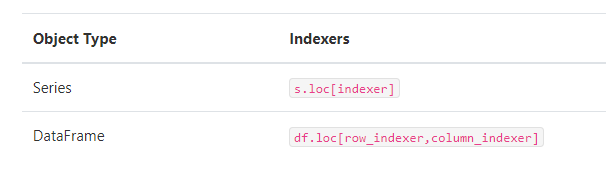

The primary function of indexing with [] (a.k.a. __getitem__ for those familiar with implementing class behavior in Python) is selecting out lower-dimensional slices. The following table shows return type values when indexing pandas objects with []:

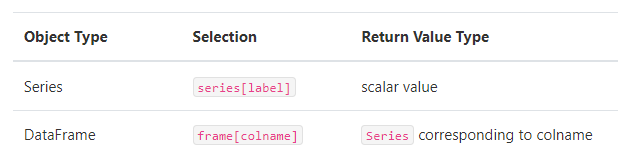




In [ ]:
# The main distinction between loc and iloc is:
# loc is label-based, which means that you have to specify rows and columns based on their row and column labels.
# iloc is integer position-based, so you have to specify rows and columns by their integer position values (0-based integer position).

In [ ]:
# Using loc

In [ ]:
carat_good = df.loc[df["carat"] > 0.31, "price"]

In [ ]:
carat_good.head()

In [ ]:
# Here, a subset of both rows and columns is made in one go and just using selection brackets [] is not sufficient anymore. 
# The loc/iloc operators are required in front of the selection brackets []. When using loc/iloc, the part before the comma is the rows you want, and the part after the comma is the columns you want to select.
# When using the column names, row labels or a condition expression, use the loc operator in front of the selection brackets []. For both the part before and after the comma, you can use a single label, a list of labels, a slice of labels, a conditional expression or a colon. Using a colon specifies you want to select all rows or columns

#### Note:
* When selecting subsets of data, square brackets [] are used.
* Inside these brackets, you can use a single column/row label, a list of column/row labels, a slice of labels, a conditional expression or a colon.
* Select specific rows and/or columns using loc when using the row and column names.
* Select specific rows and/or columns using iloc when using the positions in the table.
* You can assign new values to a selection based on loc/iloc.

In [ ]:
# Indexing just the rows
df.iloc[1]

In [ ]:
type(df.iloc[1])

In [ ]:
# With a list of integers.
df.iloc[[1]]

In [ ]:
type(df.iloc[[1]])

In [ ]:
# With a slice object.
df.iloc[0:3]

In [ ]:
df.iloc[[1,2]]

In [ ]:
# With a callable, useful in method chains. The x passed to the lambda is the DataFrame being sliced. This selects the rows whose index label even.
df.iloc[lambda x: x.index % 3 == 0].head()

In [ ]:
# With lists of integers.
df.iloc[[0, 2], [1, 3]]

In [ ]:
# With slice objects.
df.iloc[1:3, 0:3]

In [ ]:
# With a callable function that expects the Series or DataFrame.
df.iloc[2:7, lambda df: [1, 5]]

In [ ]:
# Single label. Returns the row as a Series.
df.loc[1]

In [ ]:
type(df.loc[1])

In [ ]:
# List of labels. Note using [[]] returns a DataFrame.
df.loc[[0,1]]

In [ ]:
# Single label for row and column
df.loc[0,"carat"]

In [ ]:
# Slice with labels for row and single label for column. As mentioned above, note that both the start and stop of the slice are included.
df.loc[0:1, "cut"]

In [ ]:
# Conditional that returns a boolean Series
df.loc[df["carat"] > 4.0]

In [ ]:
# Conditional that returns a boolean Series with column labels specified
carat_price = df.loc[df["carat"] > 0.21, "price"]
carat_price.head()

In [ ]:
# Callable that returns a boolean Series
df.loc[lambda df: df["carat"] == 4]

In [ ]:
df[0:1]

In [ ]:
df.loc[0:3]

In [ ]:
df.iloc[0:3]

In [ ]:
df.iloc[0:3]["cut"]

In [ ]:
# To create new columns derived from existing columns

In [ ]:
# If we assumme that regulated "new price" is 1500 times of "price" of carat.
# To create a new column, use the [] brackets with the new column name at the left side of the assignment.
# The calculation of the values is done element-wise. This means all values in the given column are multiplied by the value 1500 at once. 
# You do not need to use a loop to iterate each of the rows!

df["new_price"] = df["carat"]* 1500
df.head(6)

In [ ]:
# to check the ratio of the values in carat is versus price save the result in a new column.
df["carat_ratio_price"] = df["carat"]/df["price"]

In [ ]:
df.head(2)

In [ ]:
# The calculation is again element-wise, so the / is applied for the values in each row.
# Also other mathematical operators (+, -, *, /,…) or logical operators (<, >, ==,…) work element-wise.

In [ ]:
# I want to rename the data columns
# The rename() function can be used for both row labels and column labels. Provide a dictionary with the keys the current names and the values the new names to update the corresponding names.
# The mapping should not be restricted to fixed names only, but can be a mapping function as well

In [ ]:
df_named = df.rename(columns={"carat":"Carat","cut":"Shape","color":"Hue", "clarity":"Brightness"})   

In [ ]:
df_named.head()

In [ ]:
df.head()

### 5. Reshape The Layout of Tables <a class="anchor"  id="chapter5"></a>
##### Sorting <a class="anchor"  id="subchapter5.1"></a>

Pandas supports three kinds of sorting: 

* sorting by index labels, 
* sorting by column values, and 
* sorting by a combination of both.

In [ ]:
# By index 
sorted_by_index = df.sort_index(level= "price")
sorted_by_index.head()

In [ ]:
# By values
# The Series.sort_values() method is used to sort a Series by its values. 
# The DataFrame.sort_values() method is used to sort a DataFrame by its column or row values. 
# The optional by parameter to DataFrame.sort_values() may used to specify one or more columns to use to determine the sorted order.

sorted_by_values = df.sort_values(by= "price")
sorted_by_values.tail()

In [ ]:
sorted_by_values = df.sort_values(by= "carat")
df.head()

In [ ]:
# OR 
# With DataFrame.sort_values(), the rows in the table are sorted according to the defined column(s). The index will follow the row order.

df.sort_values(by=['carat'], ascending=False).head()

#### Long to wide table format
*  Let’s use a small subset of the diamond data set. We focus on data and only use the first two measurements of each color. 
*  The subset of data will be called no2_subset.

In [ ]:
I1 = df[df["clarity"] == "I1"]

In [ ]:
I1_subset = I1.sort_index().groupby(["cut"]).head(2)

In [ ]:
I1_subset


#### Pivoting <a class="anchor"  id="subchapter5.2"></a>

The pivot() function is purely reshaping of the data: a single value for each index/column combination is required. But suppose we wish to do time series operations with the variables. A better representation would be where the columns are the unique variables and an index of dates identifies individual observations. To reshape the data into this form, we use the DataFrame.pivot() method :

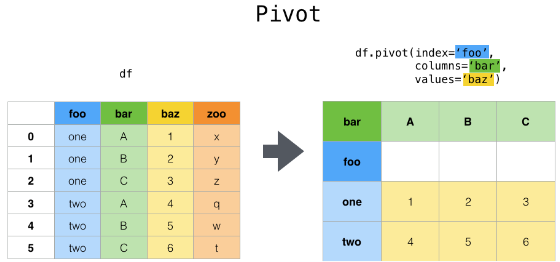

In [ ]:
df.pivot(columns="cut", values="price").head()

#### Note: 
* When the index parameter is not defined, the existing index (row labels) is used.
* In the case of pivot(), the data is only rearranged. When multiple values need to be aggregated (in this specific case, the values on different time steps), pivot_table() can be used, providing an aggregation function (e.g. mean) on how to combine these values.
* Pivot table is a well known concept in spreadsheet software. When interested in the row/column margins (subtotals) for each variable, set the margins parameter to True:


In [ ]:
df.pivot_table(values="carat",index="color",columns="cut",aggfunc="mean",margins=True)

In [ ]:
# In case you are wondering, pivot_table() is indeed directly linked to groupby(). The same result can be derived by grouping on both parameter and location:
df.groupby(["cut", "color"]).mean().head()

#### Wide to Long Format 

* The pandas.melt() method on a DataFrame converts the data table from wide format to long format. The column headers become the variable names in a newly created column.

* The solution is the short version on how to apply pandas.melt(). The method will melt all columns NOT mentioned in id_vars together into two columns: A column with the column header names and a column with the values itself. The latter column gets by default the name value.

In [ ]:
# I want to collect all carat measurements in a single column (long format).
premium_diamond = df.melt(id_vars="carat")
premium_diamond.head()

In [ ]:
# The parameters passed to pandas.melt() can be defined in more detail:

# pd.melt(df, id_vars=['A'], value_vars=['B'], var_name='myVarname', value_name='myValname')

# The additional parameters have the following effects:

# value_vars defines which columns to melt together

# value_name provides a custom column name for the values column instead of the default column name value

# var_name provides a custom column name for the column collecting the column header names. Otherwise it takes the index name or a default variable

# Hence, the arguments value_name and var_name are just user-defined names for the two generated columns. The columns to melt are defined by id_vars and value_vars.

#### Note:

* Sorting by one or more columns is supported by sort_values.
* The pivot function is purely restructuring of the data, pivot_table supports aggregations.
* The reverse of pivot (long to wide format) is melt (wide to long format)

### 6. Descriptive Statistics <a class="anchor"  id="chapter6"></a>
#### Summarize Data <a class="anchor"  id="subchapter6.1"></a>

* There exists a large number of methods for computing descriptive statistics and other related operations on Series, DataFrame. Most of these are aggregations (hence producing a lower-dimensional result) like sum(), mean(), and quantile(), but some of them, like cumsum() and cumprod(), produce an object of the same size. Generally speaking, these methods take an axis argument, just like ndarray.{sum, std, …}, but the axis can be specified by name or integer:
* Series: no axis argument needed
* DataFrame: “index” (axis=0, default), “columns” (axis=1)

In [ ]:
# Generates descriptive statistics. It describes the summary of all numerical columns in the dataframe.
# There is a convenient describe() function which computes a variety of summary statistics about a Series or the columns of a DataFrame (excluding NAs of course)
# For a non-numerical Series object, describe() will give a simple summary of the number of unique values and most frequently occurring values:

df. describe() 

In [ ]:
# What is the average price of the dimanonds?
df["price"].mean()

In [ ]:
# What is the median carat and price of the diamond.
df[["carat","price"]].median()

In [ ]:
# Different statistics are available and can be applied to columns with numerical data. Operations in general exclude missing data and operate across rows by default.

In [ ]:
# Instead of the predefined statistics, specific combinations of aggregating statistics for given columns can be defined using the DataFrame.agg() method:
df.agg({"carat":["min", "max", "median", "skew"],"price": ["min", "max", "median", "skew"]})

#### Aggregation <a class="anchor"  id="subchapter6.2"></a>

Aggregating statistics grouped by category.
The aggregation operations are always performed over an axis, either the index (default) or the column axis. This behavior is different from numpy aggregation functions (mean, median, prod, sum, std, var), where the default is to compute the aggregation of the flattened array, e.g., numpy.mean(arr_2d) as opposed to numpy.mean(arr_2d, axis=0).The aggregation operations are always performed over an axis, either the index (default) or the column axis. This behavior is different from numpy aggregation functions (mean, median, prod, sum, std, var), where the default is to compute the aggregation of the flattened array, e.g., numpy.mean(arr_2d) as opposed to numpy.mean(arr_2d, axis=0).

In [ ]:
# What is the average cut for price?
df.groupby("cut")["price"].mean(numeric_only = True)

In [ ]:
# Calculating a given statistic (mean price) for each category in a column is a common pattern. 

# The groupby method is used to support this type of operations. This fits in the more general split-apply-combine pattern:

# Split the data into groups

# Apply a function to each group independently

# Combine the results into a data structure

# The apply and combine steps are typically done together in pandas.

In [ ]:
# What is the number of diamonds in each of the cut classes?
# the value_counts() method counts the number of records for each category in a column.

df["cut"].value_counts()

In [ ]:
# The function is a shortcut, as it is actually a groupby operation in combination with counting of the number of records within each group:
df.groupby("cut")["cut"].count()

#### Note: 

* Both size and count can be used in combination with groupby. 
* Whereas size includes NaN values and just provides the number of rows (size of the table), count excludes the missing values. 
* In the value_counts method, use the dropna argument to include or exclude the NaN values.

### 7. Working with Time Series  <a class="anchor"  id="chapter7"></a>

In [ ]:
# I want to work with the dates in the column datetime as datetime objects instead of plain text
spacex = pd.read_csv("../input/spacex-missions/database.csv")

SpaceX has gained worldwide attention for a series of historic milestones. It is the only private company ever to return a spacecraft from low-Earth orbit, which it first accomplished in December 2010. The company made history again in May 2012 when its Dragon spacecraft attached to the International Space Station, exchanged cargo payloads, and returned safely to Earth — a technically challenging feat previously accomplished only by governments. Since then Dragon has delivered cargo to and from the space station multiple times, providing regular cargo resupply missions for NASA.
This dataset includes a record for each payload carried during a SpaceX mission into outer space.

In [ ]:
col = [i.replace(' ', '_') for i in spacex.columns ]
spacex.columns = col
spacex.head()

In [ ]:
# Initially, the values in datetime are character strings and do not provide any datetime operations (e.g. extract the year, day of the week,…). 
# By applying the to_datetime function, pandas interprets the strings and convert these to datetime (i.e. datetime64[ns, UTC]) objects.
# In pandas we call these datetime objects similar to datetime.datetime from the standard library as pandas.Timestamp.

In [ ]:
spacex["Launch_Date"] = pd.to_datetime(spacex["Launch_Date"])
spacex["Launch_Date"]

In [ ]:
# As many data sets do contain datetime information in one of the columns, pandas input function like pandas.read_csv() and pandas.read_json() can do the transformation to dates when reading the data using the parse_dates parameter with a list of the columns to read as Timestamp:

# pd.read_csv("../input/time-series-starter-dataset/Month_Value_1.csv"), parse_dates=["datetime"])

In [ ]:
# The start and end date of the time series data set we are working with.
spacex["Launch_Date"].min(),spacex["Launch_Date"].max()

In [ ]:
# Using pandas.Timestamp for datetimes enables us to calculate with date information and make them comparable. Hence, we can use this to get the length of our time series:
spacex["Launch_Date"].max() - spacex["Launch_Date"].min()

In [ ]:
# The result is a pandas.Timedelta object, similar to datetime.timedelta from the standard Python library and defining a time duration
# I want to add a new column to the DataFrame containing only the month of the measurement.
spacex["month"] = spacex["Launch_Date"].dt.month

In [ ]:
spacex.head()

In [ ]:
# What is the average Payload_Mass for each of the week for each of the Flight_Number?

payloads = spacex.groupby([spacex["Launch_Date"].dt.month,"Launch_Site"])["Payload_Mass_(kg)"].mean()
payloads

In [ ]:
# Here, I want to calculate a given statistic (e.g. mean ) for each month and for each Launch_Site. To group on months, we use the datetime property month (with Monday=0 and Sunday=6) of pandas Timestamp, which is also accessible by the dt accessor. The grouping on Launch_Site and months can be done to split the calculation of the mean on each of these combinations.

In [ ]:
# Plot the typical pattern during the day of our time series of all regions together. In other words, what is the average sales_quantity for each hour of the day?

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
fig, axs = plt.subplots(figsize=(10, 4))

spacex.groupby(spacex["Launch_Date"].dt.month)["Payload_Mass_(kg)"].mean().plot(kind='bar', rot=0, ax=axs)

plt.xlabel("Month of the Launch_Date");  # custom x label using Matplotlib

plt.ylabel("Payload_Mass_(kg)");

#### Datetime as index

* One of the main uses for DatetimeIndex is as an index for pandas objects. The DatetimeIndex class contains many time series related optimizations:
* A large range of dates for various offsets are pre-computed and cached under the hood in order to make generating subsequent date ranges very fast (just have to grab a slice).
* Fast shifting using the shift method on pandas objects.

* Unioning of overlapping DatetimeIndex objects with the same frequency is very fast (important for fast data alignment).

* Quick access to date fields via properties such as year, month, etc.

* Regularization functions like snap and very fast asof logic.

* DatetimeIndex objects have all the basic functionality of regular Index objects, and a smorgasbord of advanced time series specific methods for easy frequency processing.

In [ ]:
# In the Reshaping and pivot tables, pivot() was introduced to reshape the data table with each of the measurements locations as a separate column: 
payload = spacex.pivot_table(index="Launch_Date", columns="Launch_Site", values="Payload_Mass_(kg)")
payload.head()

In [ ]:
# Working with a datetime index (i.e. DatetimeIndex) provides powerful functionalities. 
payload.index.year

In [ ]:
payload.index.weekday

#### Resample a time series to another frequency
* Aggregate the current time series values to the monthly maximum value in each of the Launch_Site.
* A very powerful method on time series data with a datetime index, is the ability to resample() time series to another frequency (e.g., converting secondly data into 5-minutely data)
* The resample() method is similar to a groupby operation:
* It provides a time-based grouping, by using a string (e.g. M, 5H,…) that defines the target frequency
* It requires an aggregation function such as mean, max,…


In [ ]:
monthly_max = payload.resample("M").max()
monthly_max.head()

In [ ]:
#Make a plot of the monthly mean value in each of the stations.
payload.resample("M").mean().plot(style="-o", figsize=(10, 5));

#### Note:

* Valid date strings can be converted to datetime objects using to_datetime function or as part of read functions.
* Datetime objects in pandas support calculations, logical operations and convenient date-related properties using the dt accessor.
* A DatetimeIndex contains these date-related properties and supports convenient slicing.
* Resample is a powerful method to change the frequency of a time series.

### 8. Working with Star Wars datasets as an Example  <a class="anchor"  id="chapter8"></a>

In [ ]:
# Lets use Star Wars datasets for this topic
sw = pd.read_csv("../input/star-wars/characters.csv")
sw.head()

In [ ]:
# The set_index() function is used to set the DataFrame index using existing columns. Set the DataFrame index (row labels) using one or more existing columns or arrays of the correct length. The index can replace the existing index or expand on it.
# df.set_index()
sw = sw.set_index("name")
sw.head()

In [ ]:
# GETTING VALUES
# Single label. Returns the row as a Series.
sw.loc["Darth Vader"]

In [ ]:
# List of labels. Note using [[]] returns a DataFrame.
sw.loc[["Darth Vader","C-3PO"]].head()

In [ ]:
# Single label for row and column
sw.loc["Darth Vader", "species"]

In [ ]:
# Slice with labels for row and single label for column. As mentioned above, note that both the start and stop of the slice are included.
sw.loc["Darth Vader" : "Leia Organa", "species"]

In [ ]:
# Index (same behavior as df.reindex)
# The reindex() method allows you to change the row indexes, and the columns labels.
sw.loc[pd.Index(["Darth Vader","C-3PO"], name="foo")]

In [ ]:
# Conditional that returns a boolean Series, that returns a boolean Series with column labels specified
sw.loc[sw["height"] > 200, "gender"]

In [ ]:
# Callable that returns a boolean Series
sw.loc[lambda df: df["homeworld"] == "Tatooine"]

In [ ]:
# SETTING VALUES
# Set value for all items matching the list of labels
sw.loc[["Owen Lars","C-3PO"], ["mass"]] = 75

In [ ]:
# you can see the setted value as below.
sw.loc[["Owen Lars","C-3PO"]].head(10)

In [ ]:
# Set value for an entire column

sw.loc[:,"mass"] = 75
sw.head()

In [ ]:
# In the “gender” column, replace values of “male” by “M” and values of “female” by “F”.

sw["gender_short"] = sw["gender"].replace({"male": "M", "female": "F"})


In [ ]:
sw["gender_short"]

In [ ]:
# Whereas replace() is not a string method, it provides a convenient way to use mappings or vocabularies to translate certain values. 
# It requires a dictionary to define the mapping {from : to}.

#### Note: 

* String methods are available using the str accessor.

* String methods work element-wise and can be used for conditional indexing.

* The replace method is a convenient method to convert values according to a given dictionary.

### 9. Create Plots in Pandas  <a class="anchor"  id="chapter9"></a>

#### Basic Plotting: plot <a class="anchor"  id="subchapter9.1"></a>

The plot method on Series and DataFrame is just a simple wrapper around plt.plot(). 

Plotting methods allow for a handful of plot styles other than the default line plot. 

Apart from the default line plot when using the plot function, a number of alternatives are available to plot data. Let’s use some standard Python to get an overview of the available plot methods:

* ‘bar’ or ‘barh’ for bar plots

* ‘hist’ for histogram

* ‘box’ for boxplot

* ‘kde’ or ‘density’ for density plots

* ‘area’ for area plots

* ‘scatter’ for scatter plots

* ‘hexbin’ for hexagonal bin plots

* ‘pie’ for pie plots

In [ ]:
# The simplest way of creating a Figure with an Axes is using pyplot.subplots. We can then use Axes.plot to draw some data on the Axes:
# fig, ax = plt.subplots()  
# Create a figure containing a single axes.
# ax.plot([1, 2, 3, 4], [1, 4, 2, 3]); 
# Plot some data on the axes. 

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# The whole figure. The Figure keeps track of all the child Axes, a group of 'special' Artists (titles, figure legends, colorbars, etc), and even nested subfigures.
# The easiest way to create a new Figure is with pyplot:
# fig = plt.figure() 
# an empty figure with no Axes
# fig, ax = plt.subplots() 
# a figure with a single Axes
# fig, axs = plt.subplots(2, 2)  
# a figure with a 2x2 grid of Axes
# It is often convenient to create the Axes together with the Figure, but you can also manually add Axes later on.

In [ ]:
# Lets use World Happiness Report 2022 dataset, which uses global survey data to report how people evaluate their own lives in more than 150 countries worldwide. 

In [ ]:
hppi = pd.read_csv("/kaggle/input/world-happiness-report-2022/rankings.csv")
hppi.head()

In [ ]:
hppi = hppi.drop("RANK", axis = 1)

In [ ]:
# Lets a quick visual check of the data.
# With a DataFrame, pandas creates by default one line plot for each of the columns with numeric data.

hppi.plot(figsize = (10,10))


#### Matplotlib <a class="anchor"  id="subchapter9.2"></a>

Matplotlib graphs your data on Figures (e.g., windows, Jupyter widgets, etc.), each of which can contain one or more Axes, an area where points can be specified in terms of x-y coordinates (or theta-r in a polar plot, x-y-z in a 3D plot, etc). 

In some situations it may still be preferable or necessary to prepare plots directly with matplotlib, for instance when a certain type of plot or customization is not (yet) supported by pandas. Series and DataFrame objects behave like arrays and can therefore be passed directly to matplotlib functions without explicit casts.

Pandas also automatically registers formatters and locators that recognize date indices, thereby extending date and time support to practically all plot types available in matplotlib. Although this formatting does not provide the same level of refinement you would get when plotting via pandas, it can be faster when plotting a large number of points.

#### Figure

In [ ]:
# I want to plot only the columns of the data table with the data from Happiness score.
hppi["Happiness score"].plot()

In [ ]:
# I want to visually compare the values measured in Avatar versus Spectre.

hppi.plot.scatter(x="Happiness score", y="Explained by: Freedom to make life choices", c='b', alpha=0.5, figsize= (10,7))

#### Note: 
In many development environments as well as IPython and Jupyter Notebook, use the TAB button to get an overview of the available methods, for example movie.plot + TAB

#### Boxplot <a class="anchor"  id="subchapter9.3"></a>

In [ ]:
# One of the options is DataFrame.plot.box(), which refers to a boxplot. 
box_plot = hppi.boxplot(figsize = (20,10), fontsize = 7, rot = 0.15)

In [ ]:
# I want each of the columns in a separate subplot.

axs = hppi.plot.area(figsize=(15, 10), subplots=True)

In [ ]:
# I want to further customize, extend or save the resulting plot. 
# Each of the plot objects created by pandas is a Matplotlib object. 
# As Matplotlib provides plenty of options to customize plots, making the link between pandas and Matplotlib explicit enables all the power of Matplotlib to the plot. 

fig, axs = plt.subplots(figsize=(10,8))        # Create an empty Matplotlib Figure and Axes
hppi.plot.area(ax=axs)                            # Use pandas to put the area plot on the prepared Figure/Axes
axs.set_ylabel("Happiness_number")              # Do any Matplotlib customization you like
fig.savefig("Happiness_Metric.png")             # Save the Figure/Axes using the existing Matplotlib method.
plt.show()                                      # Display the plot

#### Bar plot <a class="anchor"  id="subchapter9.4"></a>

A bar plot is a plot that presents categorical data with rectangular bars with lengths proportional to the values that they represent. A bar plot shows comparisons among discrete categories. One axis of the plot shows the specific categories being compared, and the other axis represents a measured value.

A histogram can be stacked using stacked=True. Bin size can be changed using the bins keyword.

In [ ]:
plt.figure()
hppi.plot.hist(stacked=True, figsize=(15, 10), bins=30);

### Further Information 
* Seaborn: https://www.kaggle.com/kanncaa1/seaborn-for-beginners
* Bokeh 1: https://www.kaggle.com/kanncaa1/interactive-bokeh-tutorial-part-1
* Rare Visualization: https://www.kaggle.com/kanncaa1/rare-visualization-tools
* Plotly: https://www.kaggle.com/kanncaa1/plotly-tutorial-for-beginners